# E蛋白突变体 CCK8 值预测与相关性分析

### 目的
本脚本旨在加载一个训练好的模型，对E蛋白突变体的Stage 1数据集进行推理，预测每个突变体的`CCK8`值。然后，将预测值与数据集中的真实`CCK8`值进行比较，通过计算相关系数和绘制散点图来评估模型的预测性能。

### 流程
1.  **参数配置**：设置所有文件路径，包括模型检查点路径和输入数据路径。
2.  **加载模型**：根据配置文件和指定的模型检查点，加载训练好的模型。
3.  **加载数据**：使用`Dataset`和`DataLoader`加载`CCK8-2single.pkl`文件，以实现高效的批处理。
4.  **执行推理**：遍历`DataLoader`中的每一个批次，获取模型的`CCK8`预测值，并收集对应的真实值。
5.  **相关性分析与可视化**：
    a. 计算预测值与真实值之间的皮尔逊（Pearson）和斯皮尔曼（Spearman）相关系数。
    b. 绘制散点图，直观地展示预测值与真实值之间的关系。

### 1. 导入所需库

In [1]:
import os
import json
import pickle
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import pearsonr, spearmanr

# 导入本地工具模块 (请确保这些脚本在您的Python环境中可用)
import trainUtils
import VirusDataset
from esm.models.esm3 import ESM3

### 2. 参数配置

In [2]:
PATH = "/data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_pearson/k4/"
CONFIG_FILE = os.path.join(PATH, "config.json")
CHECKPOINT_FILE = os.path.join(PATH, "epoch=154-validation_pearson=1.8456.ckpt") 

DATA_PATH = "/data2/zhoukaitao/01evoModel/dataset/251124_E_Mut_R2/E_Mut_R2.pkl"

DEVICE = "cuda:0"
BATCH_SIZE = 1
print(f"模型配置路径: {CONFIG_FILE}")
print(f"模型权重路径: {CHECKPOINT_FILE}")
print(f"将使用设备: {DEVICE}")

模型配置路径: /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_pearson/k4/config.json
模型权重路径: /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_pearson/k4/epoch=154-validation_pearson=1.8456.ckpt
将使用设备: cuda:0


### 3. 加载模型

In [3]:
with open(CONFIG_FILE, "r") as f:
    configs = json.load(f)
pretrain_model = trainUtils.loadPretrainModel(configs)
model = trainUtils.buildModel(configs, pretrain_model, CHECKPOINT_FILE)

model.eval()
model.to(DEVICE)

load local model: /data2/zhoukaitao/01evoModel/checkpoints/250813_stage1_test/pretrain_stage1_250824.pth
model at stage: training stage 1
INFO: Using original Regressors for backward compatibility.


/home/zhoukaitao/anaconda3/envs/esm3/lib/python3.10/site-packages/torch/nn/init.py:452: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


incompatible parameters ['stage_1_regressors.clf.3.weight', 'stage_1_regressors.clf.3.bias']
finish loading parameters
load model from checkpoint /data2/zhoukaitao/01evoModel/checkpoints/251003_E_Mut_4fold_pearson/k4/epoch=154-validation_pearson=1.8456.ckpt


VESM(
  (esm_model): ESMModule(
    (esm_model): ESM3(
      (encoder): EncodeInputs(
        (sequence_embed): Embedding(64, 1536)
        (plddt_projection): Linear(in_features=16, out_features=1536, bias=True)
        (structure_per_res_plddt_projection): Linear(in_features=16, out_features=1536, bias=True)
        (structure_tokens_embed): Embedding(4101, 1536)
        (ss8_embed): Embedding(11, 1536)
        (sasa_embed): Embedding(19, 1536)
        (function_embed): ModuleList(
          (0-7): 8 x Embedding(260, 192, padding_idx=0)
        )
        (residue_embed): EmbeddingBag(1478, 1536, mode='sum', padding_idx=0)
      )
      (transformer): TransformerStack(
        (blocks): ModuleList(
          (0): UnifiedTransformerBlock(
            (attn): MultiHeadAttention(
              (layernorm_qkv): Sequential(
                (0): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
                (1): Linear(in_features=1536, out_features=4608, bias=False)
              )

### 4. 加载数据并执行推理

In [13]:
# --- 辅助模块：用于批处理数据 (与之前脚本类似) ---
class Stage1Dataset(torch.utils.data.Dataset):
    def __init__(self, pkl_data): self.data = pkl_data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

def collate_fn(batch):
    collated_batch = {}
    collated_batch['ids'] = [sample['id'] for sample in batch]
    collated_batch['Expression'] = torch.tensor([sample['Expression'] for sample in batch], dtype=torch.float32)
    collated_batch['CCK8'] = torch.tensor([sample['CCK8'] for sample in batch], dtype=torch.float32)
    collated_batch['Activation'] = torch.tensor([sample['Activation'] for sample in batch], dtype=torch.float32)
    # 如果您的数据中还有Expression，也可以一起加载，即使模型不用
    # if 'Expression' in batch[0]:
    #     collated_batch['Expression'] = torch.tensor([sample['Expression'] for sample in batch], dtype=torch.float32)

    prot_name = 'E'
    seq_t_list = [torch.from_numpy(sample[prot_name]['seq_t']) for sample in batch]
    collated_batch.setdefault(prot_name, {})['seq_t'] = torch.stack(seq_t_list)
    struct_t_list = [torch.from_numpy(sample[prot_name]['structure_t']) for sample in batch]
    collated_batch.setdefault(prot_name, {})['structure_t'] = torch.stack(struct_t_list)
    aligned_key = f'aligned_{prot_name}'
    aligned_seq_t_list = [torch.from_numpy(sample[aligned_key]['seq_t']) for sample in batch]
    collated_batch.setdefault(aligned_key, {})['seq_t'] = torch.stack(aligned_seq_t_list)
    aligned_struct_t_list = [torch.from_numpy(sample[aligned_key]['structure_t']) for sample in batch]
    collated_batch.setdefault(aligned_key, {})['structure_t'] = torch.stack(aligned_struct_t_list)
    return collated_batch

# --- 主处理循环 ---
try:
    with open(DATA_PATH, 'rb') as f:
        dataset_pkl = pickle.load(f)
except FileNotFoundError:
    print(f"错误: 找不到输入的数据文件: {DATA_PATH}")
    raise

dataset = Stage1Dataset(dataset_pkl)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

true_scores_exp = []
true_scores_CCK8 = []
true_scores_act = []
predicted_scores_exp = []
predicted_scores_CCK8 = []
predicted_scores_act = []

with torch.no_grad():
    for batch in tqdm(loader, desc="正在推理"):
        # 收集真实值
        true_scores_exp.extend(batch['Expression'].numpy())
        true_scores_CCK8.extend(batch['CCK8'].numpy())
        true_scores_act.extend(batch['Activation'].numpy())
        
        # 准备模型输入并移动到设备
        model_input = {}
        model_input['E'] = batch['E']
        model_input['aligned_E'] = batch['aligned_E']
        for key in model_input:
            for tensor_key in model_input[key]:
                model_input[key][tensor_key] = model_input[key][tensor_key].to(DEVICE)

        # 模型推理
        output = model(model_input)
        
        # 提取Expression预测值
        # 假设模型输出结构为 output.S1Predicts['E']['Expression']
        preds_exp = output.S1Predicts['E']['predictions'][0][0].squeeze().cpu().numpy()
        preds_CCK8 = output.S1Predicts['E']['predictions'][0][1].squeeze().cpu().numpy()
        preds_act = output.S1Predicts['E']['predictions'][0][2].squeeze().cpu().numpy()
        
        predicted_scores_exp.extend(preds_exp if preds_exp.ndim > 0 else [preds_exp])
        predicted_scores_CCK8.extend(preds_CCK8 if preds_CCK8.ndim > 0 else [preds_CCK8])
        predicted_scores_act.extend(preds_act if preds_act.ndim > 0 else [preds_act])

print("\n推理完成！")

正在推理:   0%|          | 0/29 [00:00<?, ?it/s]


推理完成！


In [11]:
output.S1Predicts['E']['predictions'][0]

tensor([-8.1091,  1.0792,  1.4570], device='cuda:0')

In [18]:
true_scores_CCK8

[0.519788,
 0.9170613,
 0.90740407,
 0.9306951,
 0.89452773,
 0.89755744,
 0.92558247,
 1.0085213,
 0.95890945,
 1.0431738,
 0.9609924,
 1.0638139,
 1.0598373,
 1.0124978,
 0.9119487,
 1.0094681,
 0.97405815,
 1.041659,
 1.0836965,
 0.93694395,
 1.0301081,
 0.99375135,
 0.9697029,
 0.9774666,
 1.11,
 1.0439312,
 1.1094491,
 1.032191,
 1.0848327]

In [19]:
predicted_scores_act

[array(1.7548789, dtype=float32),
 array(1.7467449, dtype=float32),
 array(1.9022552, dtype=float32),
 array(1.7287835, dtype=float32),
 array(1.8365089, dtype=float32),
 array(1.8025856, dtype=float32),
 array(1.8089837, dtype=float32),
 array(1.8070586, dtype=float32),
 array(1.6628954, dtype=float32),
 array(1.7723831, dtype=float32),
 array(1.3740185, dtype=float32),
 array(1.3633451, dtype=float32),
 array(1.3488709, dtype=float32),
 array(1.2273842, dtype=float32),
 array(1.0973743, dtype=float32),
 array(1.5235531, dtype=float32),
 array(1.3301684, dtype=float32),
 array(1.416699, dtype=float32),
 array(1.3599952, dtype=float32),
 array(1.2083837, dtype=float32),
 array(1.5545367, dtype=float32),
 array(1.5880758, dtype=float32),
 array(1.4850138, dtype=float32),
 array(1.4605256, dtype=float32),
 array(0.9927978, dtype=float32),
 array(1.4818162, dtype=float32),
 array(1.6911908, dtype=float32),
 array(1.7183185, dtype=float32),
 array(1.4570001, dtype=float32)]

### 5. 相关性分析与可视化

Pearson Correlation: 0.3789
P-value: 0.04266811162233353
散点图已保存至: /data2/zhoukaitao/01evoModel/result/E_Mut_R2/R1_pred/Expression_R2_k4.png


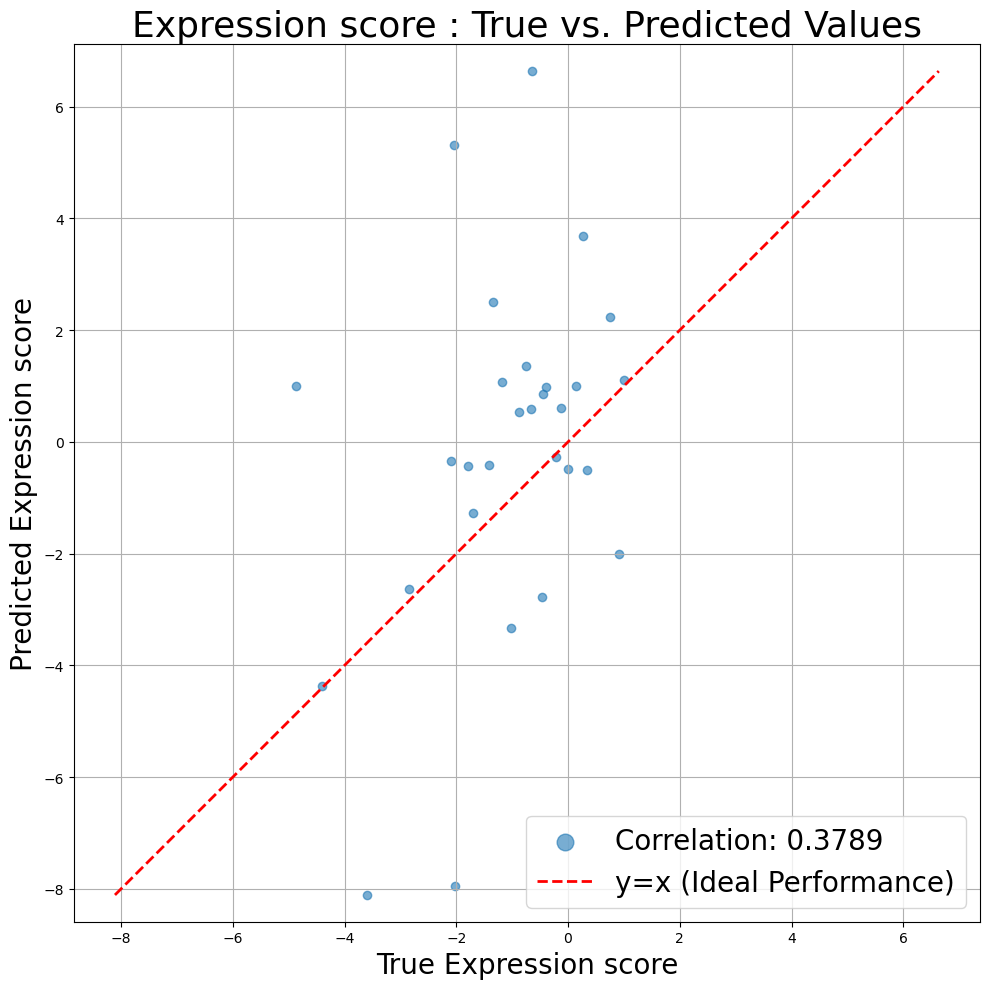

In [15]:
# 皮尔逊相关系数
correlation, p_value = pearsonr(true_scores_exp, predicted_scores_exp)
print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value}")

# 绘制散点图
plt.figure(figsize=(10, 10))
plt.scatter(true_scores_exp, predicted_scores_exp, alpha=0.6, label=f'Correlation: {correlation:.4f}')

# 绘制 y=x 参考线
min_val = min(min(true_scores_exp), min(predicted_scores_exp))
max_val = max(max(true_scores_exp), max(predicted_scores_exp))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x (Ideal Performance)')

plt.title('Expression score : True vs. Predicted Values', fontsize=26)
plt.xlabel('True Expression score', fontsize=20)
plt.ylabel('Predicted Expression score', fontsize=20)
plt.grid(True)
plt.axis('equal') # 让x和y轴的刻度等长
plt.tight_layout()

plt.legend(fontsize=20, markerscale=2)

# 保存图像
output_plot_path = os.path.join("/data2/zhoukaitao/01evoModel/result/E_Mut_R2/R1_pred/", "Expression_R2_k4.png")
plt.savefig(output_plot_path, dpi=300)
print(f"散点图已保存至: {output_plot_path}")

plt.show()

In [20]:
true_scores_CCK8

[0.519788,
 0.9170613,
 0.90740407,
 0.9306951,
 0.89452773,
 0.89755744,
 0.92558247,
 1.0085213,
 0.95890945,
 1.0431738,
 0.9609924,
 1.0638139,
 1.0598373,
 1.0124978,
 0.9119487,
 1.0094681,
 0.97405815,
 1.041659,
 1.0836965,
 0.93694395,
 1.0301081,
 0.99375135,
 0.9697029,
 0.9774666,
 1.11,
 1.0439312,
 1.1094491,
 1.032191,
 1.0848327]

Pearson Correlation: 0.1764
P-value: 0.36916622519493103
散点图已保存至: /data2/zhoukaitao/01evoModel/result/E_Mut_R2/R1_pred/CCK-8_R2_k4.png


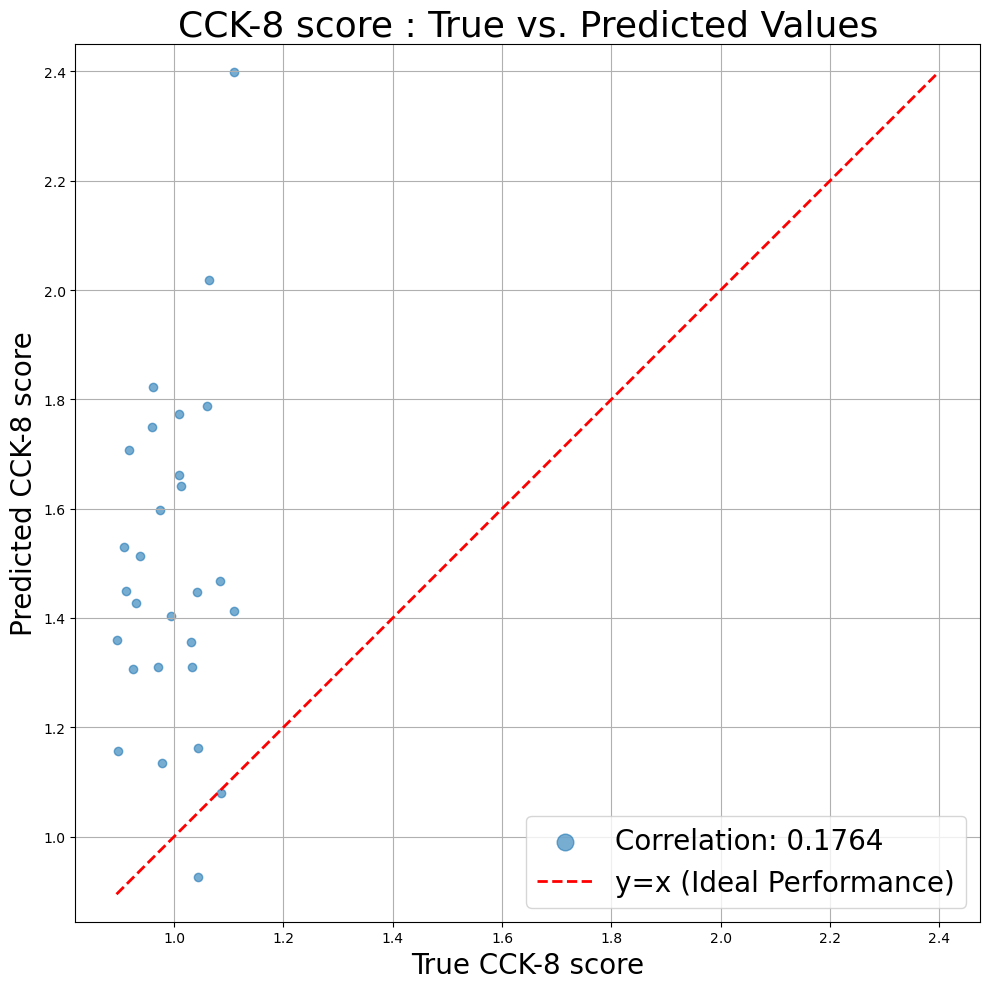

In [21]:
# 皮尔逊相关系数
correlation, p_value = pearsonr(true_scores_CCK8[1:], predicted_scores_CCK8[1:])
print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value}")

# 绘制散点图
plt.figure(figsize=(10, 10))
plt.scatter(true_scores_CCK8[1:], predicted_scores_CCK8[1:], alpha=0.6, label=f'Correlation: {correlation:.4f}')

# 绘制 y=x 参考线
min_val = min(min(true_scores_CCK8[1:]), min(predicted_scores_CCK8[1:]))
max_val = max(max(true_scores_CCK8[1:]), max(predicted_scores_CCK8[1:]))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x (Ideal Performance)')

plt.title('CCK-8 score : True vs. Predicted Values', fontsize=26)
plt.xlabel('True CCK-8 score', fontsize=20)
plt.ylabel('Predicted CCK-8 score', fontsize=20)
plt.grid(True)
plt.axis('equal') # 让x和y轴的刻度等长
plt.tight_layout()

plt.legend(fontsize=20, markerscale=2)

# 保存图像
output_plot_path = os.path.join("/data2/zhoukaitao/01evoModel/result/E_Mut_R2/R1_pred/", "CCK-8_R2_k4.png")
plt.savefig(output_plot_path, dpi=300)
print(f"散点图已保存至: {output_plot_path}")

plt.show()

Pearson Correlation: -0.2004
P-value: 0.297361820936203
散点图已保存至: /data2/zhoukaitao/01evoModel/result/E_Mut_R2/R1_pred/Activation_R2_k4.png


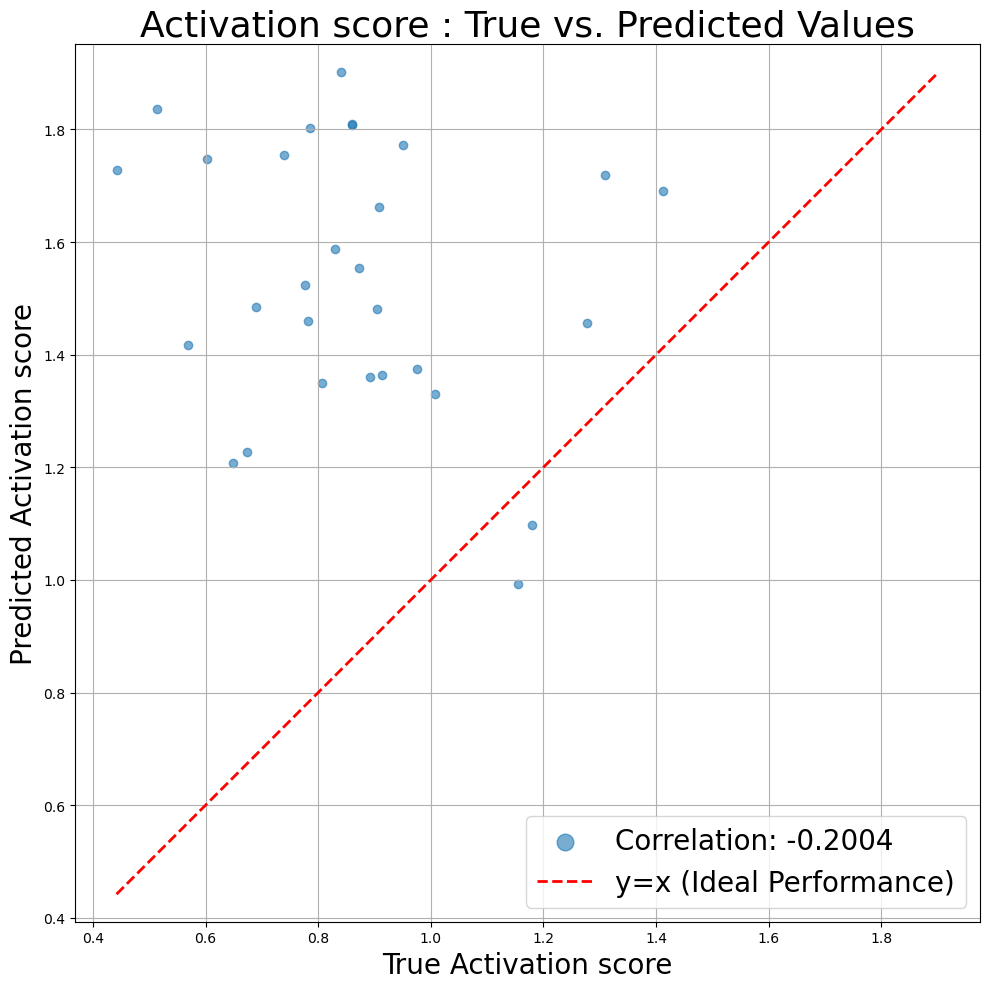

In [23]:
# 皮尔逊相关系数
correlation, p_value = pearsonr(true_scores_act, predicted_scores_act)
print(f"Pearson Correlation: {correlation:.4f}")
print(f"P-value: {p_value}")

# 绘制散点图
plt.figure(figsize=(10, 10))
plt.scatter(true_scores_act, predicted_scores_act, alpha=0.6, label=f'Correlation: {correlation:.4f}')

# 绘制 y=x 参考线
min_val = min(min(true_scores_act), min(predicted_scores_act))
max_val = max(max(true_scores_act), max(predicted_scores_act))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x (Ideal Performance)')

plt.title('Activation score : True vs. Predicted Values', fontsize=26)
plt.xlabel('True Activation score', fontsize=20)
plt.ylabel('Predicted Activation score', fontsize=20)
plt.grid(True)
plt.axis('equal') # 让x和y轴的刻度等长
plt.tight_layout()

plt.legend(fontsize=20, markerscale=2)

# 保存图像
output_plot_path = os.path.join("/data2/zhoukaitao/01evoModel/result/E_Mut_R2/R1_pred/", "Activation_R2_k4.png")
plt.savefig(output_plot_path, dpi=300)
print(f"散点图已保存至: {output_plot_path}")

plt.show()